In [1]:
import os
import sys
sys.path.append('../')
import numpy as np
import matplotlib.pyplot as plt
import os

from pydose_rt import ModelConfig
from pydose_rt.engine.data import DataGenerator
import engine.utils.plot_utils as plot_utils
import engine.utils.test_utils as test_utils

/home/rd/anaconda3/envs/autoplan/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:404: UserWarning: <built-in function array> is not a Python type (it may be an instance of an object), Pydantic will allow any object with no validation since we cannot even enforce that the input is an instance of the given type. To get rid of this error wrap the type with `pydantic.SkipValidation`.
  warn(
/home/rd/anaconda3/envs/autoplan/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
notebook_dir = os.getcwd()
parent_dir = os.path.dirname(notebook_dir)

T = test_utils.TestSetup(
    parent_dir, 
    # filedir="database/testsetup/pytorch_b003_bs01_f10_v16_d04_ptv100_fixed_DoseEngine/data_00_c1.npz",
)
T.create_real()

batch_size = 1

config = T.config
ct = T.ct
ct_np = np.expand_dims(ct, axis=0)
ct_np = np.repeat(ct_np, batch_size, axis=0)
y_mlc = T.leafs
y_mus = T.mus
data = T.data["x"]


Number of files: 1 in plotting cohort


In [3]:
T.data["x"].shape

(1, 128, 128, 320, 6)

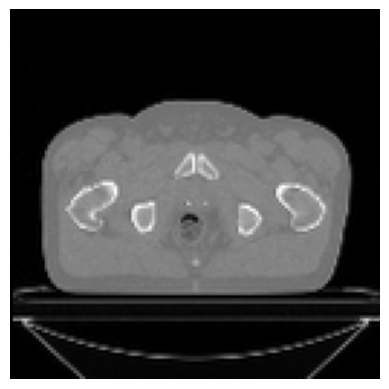

In [4]:
# Create a figure and axes
fig, ax = plt.subplots()

# Display the image on the axes
ax.imshow(ct[:, :, 160], cmap="gray")

# Hide axes
ax.axis("off")

# Display the plot with tight layout and no padding
plt.show()

fig.savefig("/home/rd/Documents/github/drawing/2025-Autoplan/figures/ct.png", bbox_inches='tight', pad_inches=0)

-1.0 1.0


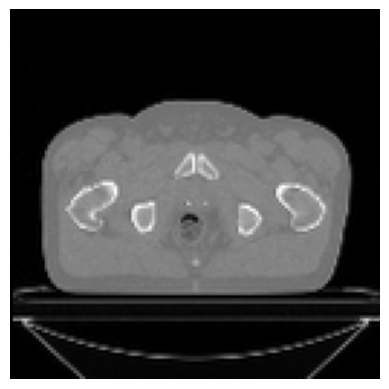

0.0 0.74


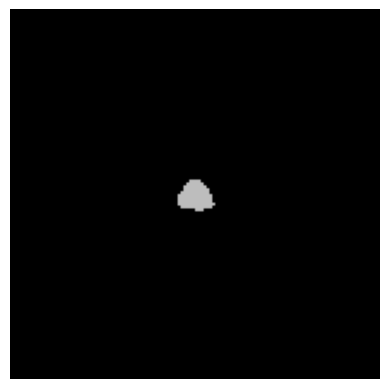

0.7 0.83


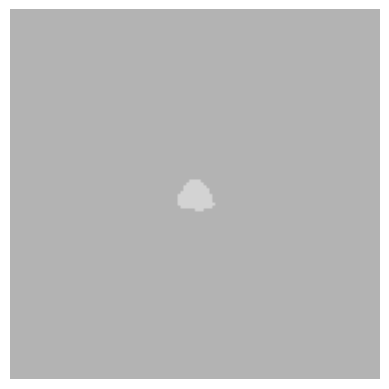

0.0 0.95


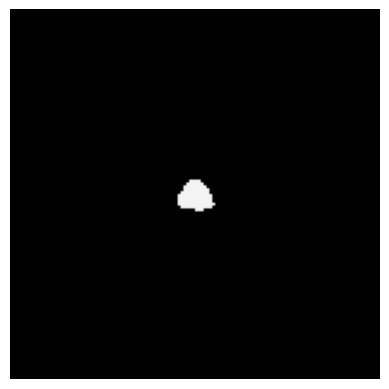

0.85 1.0


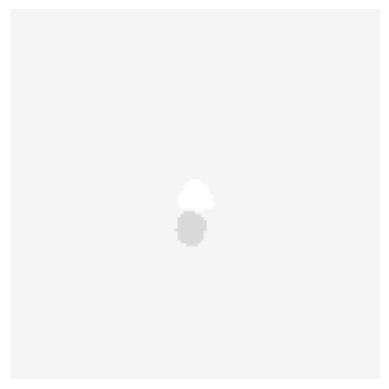

1.0 100.0


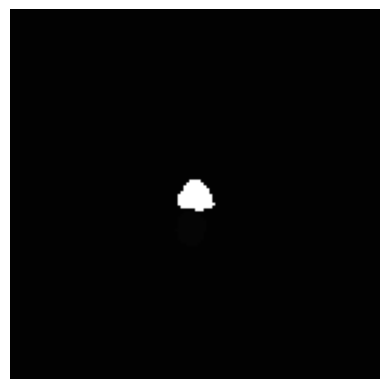

In [5]:
for i in range(data.shape[-1]):

    x = data[0,:,:,160,i]
    
    print(x.min(), x.max())
    # Create a figure and axes
    fig, ax = plt.subplots()

    if i == 0:
        name = "ct"
        ax.imshow(x, cmap="gray", vmin=-1, vmax=1)
    elif i == 1:
        name = "lgy"
        ax.imshow(x, cmap="gray", vmin=0, vmax=1)
    elif i == 2:
        name = "hgy"
        ax.imshow(x, cmap="gray", vmin=0, vmax=1)
    elif i == 3:
        name = "ltar"
        ax.imshow(x, cmap="gray", vmin=0, vmax=1)
    elif i == 4:
        name = "htar"
        ax.imshow(x, cmap="gray", vmin=0, vmax=1)
    elif i == 5:
        name = "weight"
        ax.imshow(x, cmap="gray", vmin=0, vmax=100)

    # Hide axes
    ax.axis("off")

    # Display the plot with tight layout and no padding
    plt.show()

    fig.savefig(f"/home/rd/Documents/github/drawing/2025-Autoplan/figures/{name}.png", bbox_inches='tight', pad_inches=0)

-3.8491864e-05 0.7835454


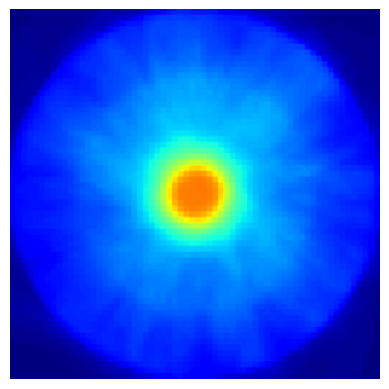

1.236376e-06 0.847726


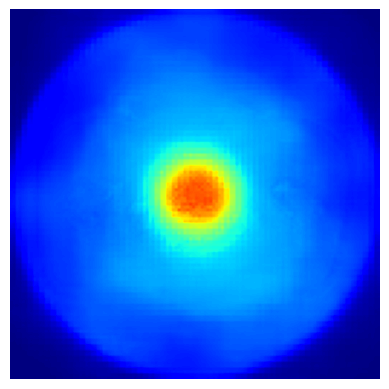

In [6]:
dose = T.data["dose"]
dose_bypass = T.data["dose_bypass"]

i = 0
for data in [dose, dose_bypass]:
    
    x = data[0,:,:,160]

    print(x.min(), x.max())
    # Create a figure and axes
    fig, ax = plt.subplots()

    if i == 0:
        name = "dose"
        ax.imshow(x, cmap="jet", vmin=0, vmax=1)
    elif i == 1:
        name = "dose_bypass"
        ax.imshow(x, cmap="jet", vmin=0, vmax=1)

    # Hide axes
    ax.axis("off")

    # Display the plot with tight layout and no padding
    plt.show()

    fig.savefig(f"/home/rd/Documents/github/drawing/2025-Autoplan/figures/{name}.png", bbox_inches='tight', pad_inches=0)
    
    i += 1

In [7]:
from pydose_rt.engine.utils.plot_utils import Plotter
print(T.data["x"].shape)
print(dose.shape)
print(T.data["masks"].shape)
print(T.data["leafs"].shape)

(1, 128, 128, 320, 6)
(1, 128, 128, 320)
(1, 128, 128, 320, 7)
(1, 2, 180, 60)


>> leafs at cp
>> create_mus
>> create_dvh


/home/rd/Documents/github/autoplan/notebooks/../engine/utils/plot_utils.py:443: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


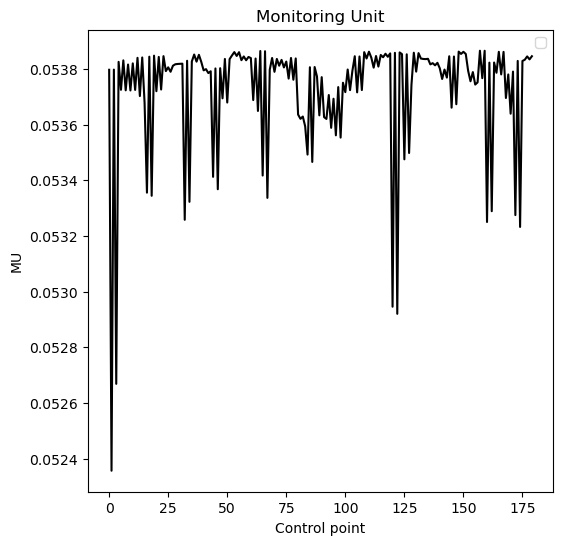

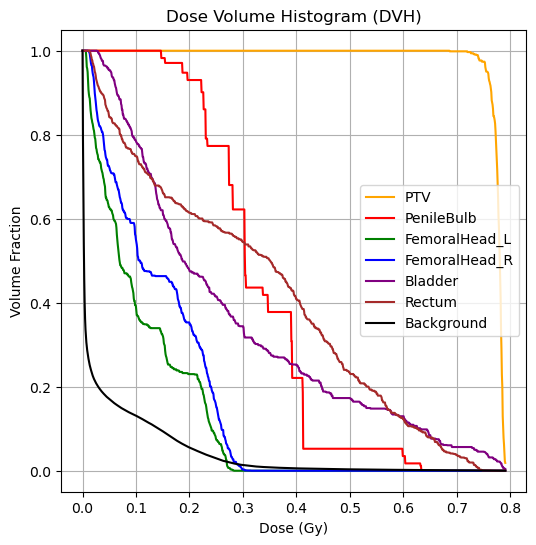

In [8]:
dose = T.data["dose"]
dose_bypass = T.data["dose_bypass"]

plotter = Plotter(
    config,
    gen_val=None,
    experiment=None,
    number_of_cps=T.data["leafs"].shape[1],
    fluence_layer=None,
    num_fluence_plots=T.data["leafs"].shape[1],
    scaled_mu=1,
    out_path="/home/rd/Documents/github/drawing/2025-Autoplan/figures",
)

plotter.make_without_model_gen(
    x=np.transpose(T.data["x"][0], (3, 0, 1, 2)),
    masks=np.transpose(T.data["masks"][0], (3, 0, 1, 2)),
    dose=dose[0],
    leafs=T.data["leafs"][0],
    mus=T.data["mus"][0],
    dose_bypass=dose_bypass[0],
    epoch=10,
    file_name="test",
    text_constraint="test",
)

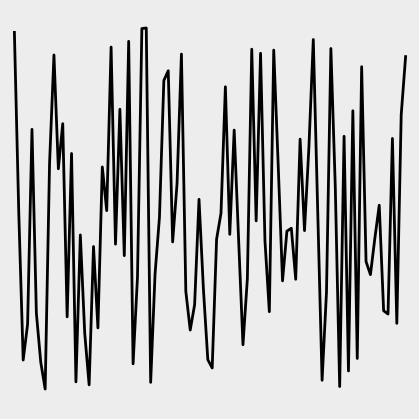

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def generate_simple_random_plot(num_samples=90, background_color="#ededed"):
    """
    Generates a clean plot with a specified number of samples (default 90).
    The y-values are random numbers between 0 and 1.

    The plot will have no visible axes, labels, ticks, or title, and a custom
    background color.

    Args:
        num_samples (int): The total number of samples (data points) to plot.
        background_color (str): The hex color code for the plot's background (e.g., "#ededed").
    """
    # X-coordinates are just the indices for the samples
    x_coordinates = np.arange(num_samples)

    # Y-values are random numbers uniformly distributed between 0 and 1
    y_values = np.random.rand(num_samples)

    # --- Plotting Configuration ---
    fig, ax = plt.subplots(figsize=(4, 4)) # Create a figure and a single subplot (Axes)

    # Set the background color for the entire figure and the plotting area (axes)
    fig.patch.set_facecolor(background_color)
    ax.set_facecolor(background_color)

    # Plot the samples as a line
    ax.plot(x_coordinates, y_values, color='black', linewidth=2) # A single black line

    # --- Remove Axes, Labels, Ticks, and Title ---
    ax.set_xticks([])    # Remove x-axis ticks
    ax.set_yticks([])    # Remove y-axis ticks
    ax.set_xlabel('')    # Remove x-axis label
    ax.set_ylabel('')    # Remove y-axis label
    ax.set_title('')     # Remove plot title
    ax.axis('off')       # Turn off the axes lines and background patch completely

    # --- Set Plot Limits (Optional, but ensures all data is visible and consistent) ---
    ax.set_xlim(-1, num_samples)  # A small margin on the x-axis
    ax.set_ylim(-0.05, 1.05)      # A small margin on the y-axis (0 to 1)

    # --- Final Layout Adjustment ---
    plt.tight_layout(pad=0) # Adjusts plot params for a tight layout, removing whitespace

    # --- Display the Plot ---
    plt.show()

# --- Example Usage ---
# Call the function to generate and display the plot
generate_simple_random_plot()